**## Week 1 — Foundations: Cleaning & Exploring the Applicant Dataset**
**Intern:** Ahmed
**Program:** NEDUET — CS&IT

In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("/content/sample_data/applicants.csv")

In [3]:
df.head()

,Applicant Name,Email,Phone,Domain Applied,University,Application Date,Status
0,Briana Murray,briana.murray948@example.com,0340-7482175,Digital Marketing,Karachi University,10/16/2025,Selected
1,Stephanie Martin,stephanie.martin371@example.com,0364-7468723,Data Science,FAST-NUCES,16-Jul-25,Under Review
2,Charles Schmidt,CHARLES.SCHMIDT195@EXAMPLE.COM,3222196937,Mobile App Development,NEDUET,08-Feb-26,Under Review
3,Audrey Young DDS,audrey.young.dds291@example.com,3586926179,Digital Marketing,Institute of Business Administration,05/12/2025,Under Review
4,Thomas Bradley,thomas.bradley100@example.com,3376724238,Mobile App Development,DHA Suffa University,04/04/2026,Under Review


In [4]:
df.shape

(95, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Applicant Name    92 non-null     object
 1   Email             87 non-null     object
 2   Phone             95 non-null     object
 3   Domain Applied    95 non-null     object
 4   University        91 non-null     object
 5   Application Date  95 non-null     object
 6   Status            92 non-null     object
dtypes: object(7)
memory usage: 5.3+ KB


In [6]:
df.isnull().sum()

,0
Applicant Name,3
Email,8
Phone,0
Domain Applied,0
University,4
Application Date,0
Status,3


In [7]:
df.duplicated().sum()

np.int64(3)

In [8]:
df.columns

Index(['Applicant Name', 'Email', 'Phone', 'Domain Applied', 'University',
       'Application Date', 'Status'],
      dtype='object')

In [9]:
before_rows=df.shape[0]
df=df.dropna(subset=["Applicant Name"])

In [10]:
print(f"Rows before: {before_rows}, rows after dropping missing names: {df.shape[0]}")

Rows before: 95, rows after dropping missing names: 92


## **HANDELING MISSING DATA**

In [11]:
df["Email"]=df["Email"].fillna("notprovided@gmail.com")

**Checking Email column for missing value**

In [12]:
df["Email"].isnull().sum()

np.int64(0)

In [13]:
df["University"]=df["University"].fillna("Not specified")
df["University"].isnull().sum()

np.int64(0)

In [14]:
df['Status'] = df['Status'].fillna('Under Review')
df['Status'].isnull().sum()

np.int64(0)

In [15]:
df.isnull().sum()

,0
Applicant Name,0
Email,0
Phone,0
Domain Applied,0
University,0
Application Date,0
Status,0


In [16]:
exact_dupl=df.duplicated().sum()
exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows found: {exact_dupes}")
df = df.drop_duplicates()
print(f"Rows after removing exact duplicates: {df.shape[0]}")

Exact duplicate rows found: 3
Rows after removing exact duplicates: 89


In [17]:
# Normalize email for comparison (strip whitespace, lowercase) without overwriting the real column yet
email_key = df['Email'].str.strip().str.lower()
near_dupes = email_key.duplicated().sum()
print(f"Additional near-duplicate applications found (same email, different formatting elsewhere): {near_dupes}")

rows_before_email_dedupe = df.shape[0]
df = df.loc[~email_key.duplicated(keep='first')]
print(f"Rows after removing near-duplicates by Email: {df.shape[0]} (removed {rows_before_email_dedupe - df.shape[0]})")

Additional near-duplicate applications found (same email, different formatting elsewhere): 7
Rows after removing near-duplicates by Email: 82 (removed 7)


# **STANDARDIZATION**

In [18]:
text_cols = ['Applicant Name', 'Email', 'University', 'Domain Applied', 'Status']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

In [19]:
df['Applicant Name'] = df['Applicant Name'].str.title()
df['Email'] = df['Email'].str.lower()

In [20]:
df['Domain Applied'].str.strip().str.lower().unique()

array(['digital marketing', 'data science', 'mobile app development',
       'web development', 'webdev', 'app dev', 'mobile dev',
       'ui/ux design', 'mobile app dev', 'data-science', 'ds',
       'digi marketing'], dtype=object)

In [21]:
domain_mapping = {
    'web development': 'Web Development',
    'web dev': 'Web Development',
    'webdev': 'Web Development',
    'data science': 'Data Science',
    'data-science': 'Data Science',
    'ds': 'Data Science',
    'mobile app development': 'Mobile App Development',
    'mobile app dev': 'Mobile App Development',
    'mobile dev': 'Mobile App Development',
    'app dev': 'Mobile App Development',
    'ui/ux design': 'UI/UX Design',
    'ui ux design': 'UI/UX Design',
    'uiux design': 'UI/UX Design',
    'ux design': 'UI/UX Design',
    'digital marketing': 'Digital Marketing',
    'digi marketing': 'Digital Marketing',
    'marketing': 'Digital Marketing',
}

df['Domain Applied'] = df['Domain Applied'].str.strip().str.lower().map(domain_mapping)
df['Domain Applied'].unique()

array(['Digital Marketing', 'Data Science', 'Mobile App Development',
       'Web Development', 'UI/UX Design'], dtype=object)

In [22]:
assert df['Domain Applied'].isnull().sum() == 0, "Unmapped domain variation found — update domain_mapping!"
print("Unique domains:", sorted(df['Domain Applied'].unique()))
print("Count:", df['Domain Applied'].nunique())

Unique domains: ['Data Science', 'Digital Marketing', 'Mobile App Development', 'UI/UX Design', 'Web Development']
Count: 5


In [23]:
df['Status'] = df['Status'].str.strip().str.title()
df['Status'].unique()

array(['Selected', 'Under Review', 'Rejected'], dtype=object)

# **FIXED DATA TYPES**

In [24]:
df['Application Date'] = pd.to_datetime(df['Application Date'], errors='coerce', format='mixed', dayfirst=True)
df['Application Date'].isnull().sum()

np.int64(0)

In [25]:
df['Phone'] = df['Phone'].str.replace('-', '', regex=False).str.replace(' ', '', regex=False)
df['Phone'].head()

,Phone
0,03407482175
1,03647468723
2,3222196937
3,3586926179
4,3376724238


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82 entries, 0 to 94
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Applicant Name    82 non-null     object        
 1   Email             82 non-null     object        
 2   Phone             82 non-null     object        
 3   Domain Applied    82 non-null     object        
 4   University        82 non-null     object        
 5   Application Date  82 non-null     datetime64[ns]
 6   Status            82 non-null     object        
dtypes: datetime64[ns](1), object(6)
memory usage: 5.1+ KB


In [27]:
print("Final shape:", df.shape)
print("\nRemaining nulls:\n", df.isnull().sum())
print("\nRemaining exact duplicates:", df.duplicated().sum())
print("\nDomain Applied categories:", df['Domain Applied'].nunique())
print("Application Date dtype:", df['Application Date'].dtype)

Final shape: (82, 7)

Remaining nulls:
 Applicant Name      0
Email               0
Phone               0
Domain Applied      0
University          0
Application Date    0
Status              0
dtype: int64

Remaining exact duplicates: 0

Domain Applied categories: 5
Application Date dtype: datetime64[ns]


# **EXPORTING CLEANED DATASET**

In [28]:
df.to_csv('applicants_cleaned.csv', index=False)
print("Saved applicants_cleaned.csv")

Saved applicants_cleaned.csv


**# Week 2 — Exploratory Data Analysis: NextGenLearners Applicant Insights**

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('applicants_cleaned.csv', parse_dates=['Application Date'])

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Applicant Name    82 non-null     object        
 1   Email             82 non-null     object        
 2   Phone             82 non-null     int64         
 3   Domain Applied    82 non-null     object        
 4   University        82 non-null     object        
 5   Application Date  82 non-null     datetime64[ns]
 6   Status            82 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 4.6+ KB


In [31]:
df.head()

,Applicant Name,Email,Phone,Domain Applied,University,Application Date,Status
0,Briana Murray,briana.murray948@example.com,3407482175,Digital Marketing,Karachi University,2025-10-16,Selected
1,Stephanie Martin,stephanie.martin371@example.com,3647468723,Data Science,FAST-NUCES,2025-07-16,Under Review
2,Charles Schmidt,charles.schmidt195@example.com,3222196937,Mobile App Development,NEDUET,2026-02-08,Under Review
3,Audrey Young Dds,audrey.young.dds291@example.com,3586926179,Digital Marketing,Institute of Business Administration,2025-12-05,Under Review
4,Thomas Bradley,thomas.bradley100@example.com,3376724238,Mobile App Development,DHA Suffa University,2026-04-04,Under Review


In [32]:
domain_counts = df['Domain Applied'].value_counts()
print(domain_counts)

Domain Applied
Web Development           22
Digital Marketing         19
Mobile App Development    19
Data Science              15
UI/UX Design               7
Name: count, dtype: int64


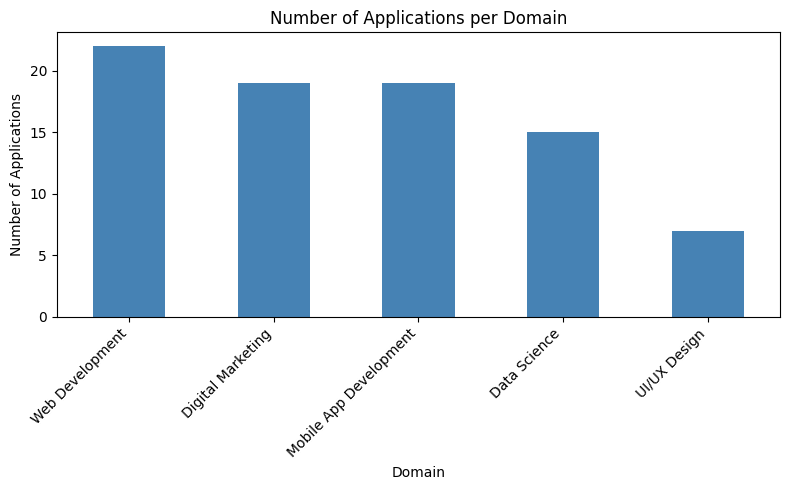

In [33]:
plt.figure(figsize=(8,5))
domain_counts.plot(kind='bar', color='steelblue')
plt.title('Number of Applications per Domain')
plt.xlabel('Domain')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [34]:
df['Application Month'] = df['Application Date'].dt.to_period('M')
monthly_trend = df.groupby('Application Month').size()
print(monthly_trend)

Application Month
2025-05     1
2025-06     1
2025-07     2
2025-08     7
2025-09     6
2025-10     6
2025-11     9
2025-12     9
2026-01     4
2026-02    10
2026-03     4
2026-04     6
2026-05     4
2026-06     7
2026-07     4
2026-08     1
2026-11     1
Freq: M, dtype: int64


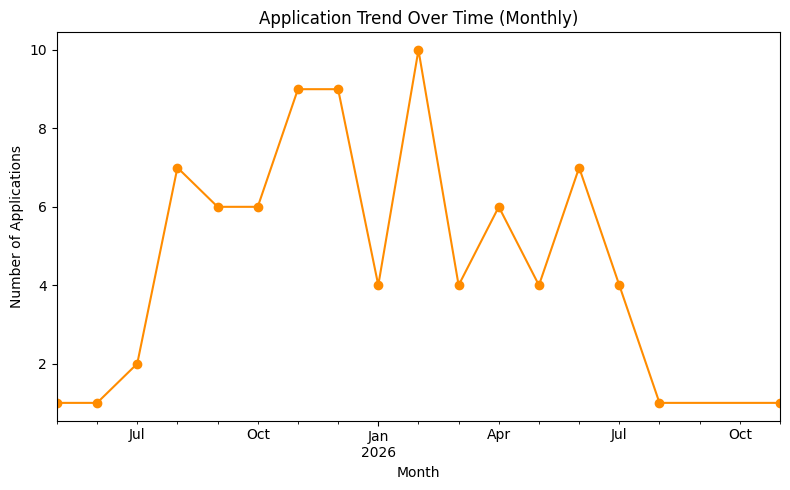

In [35]:
plt.figure(figsize=(8,5))
monthly_trend.plot(kind='line', marker='o', color='darkorange')
plt.title('Application Trend Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.tight_layout()
plt.show()

In [36]:
status_counts = df['Status'].value_counts()
print(status_counts)

Status
Under Review    32
Rejected        27
Selected        23
Name: count, dtype: int64


In [37]:
status_by_domain = pd.pivot_table(
    df,
    index='Domain Applied',
    columns='Status',
    values='Applicant Name',
    aggfunc='count',
    fill_value=0
)
print(status_by_domain)

Status                  Rejected  Selected  Under Review
Domain Applied                                          
Data Science                   5         6             4
Digital Marketing              7         5             7
Mobile App Development         6         6             7
UI/UX Design                   1         2             4
Web Development                8         4            10


In [38]:
status_by_domain_pct = status_by_domain.div(status_by_domain.sum(axis=1), axis=0) * 100
print(status_by_domain_pct.round(1))

Status                  Rejected  Selected  Under Review
Domain Applied                                          
Data Science                33.3      40.0          26.7
Digital Marketing           36.8      26.3          36.8
Mobile App Development      31.6      31.6          36.8
UI/UX Design                14.3      28.6          57.1
Web Development             36.4      18.2          45.5


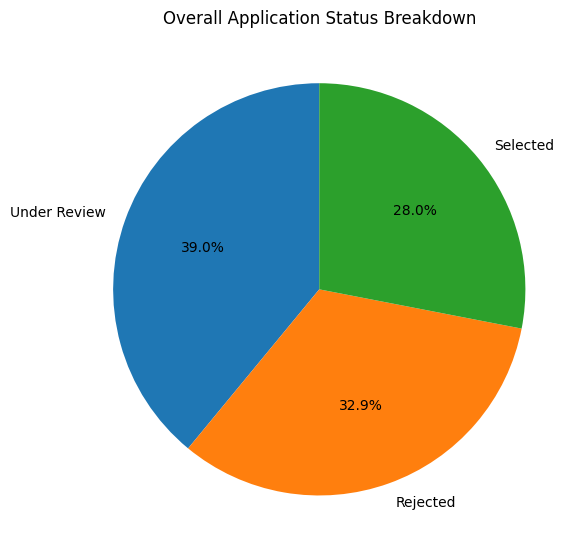

In [39]:
# Overall status - pie chart
plt.figure(figsize=(6,6))
status_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Overall Application Status Breakdown')
plt.ylabel('')
plt.tight_layout()
plt.show()

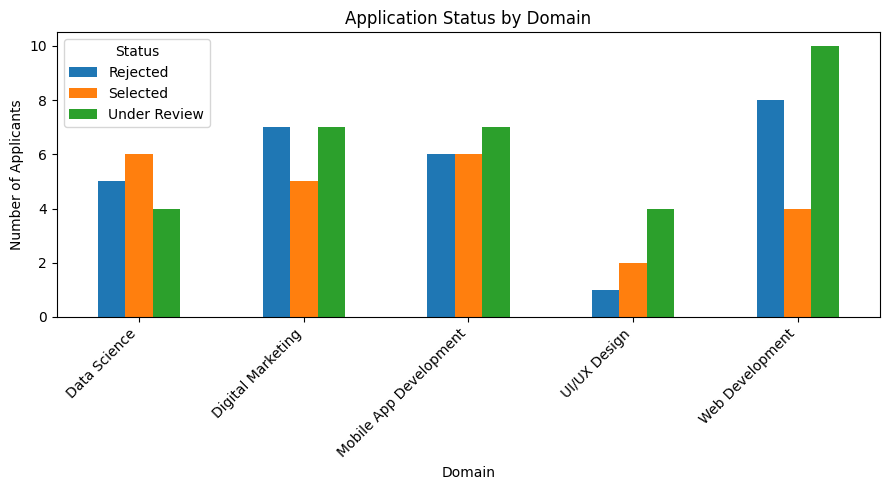

In [40]:
# Per-domain - grouped bar chart
status_by_domain.plot(kind='bar', figsize=(9,5))
plt.title('Application Status by Domain')
plt.xlabel('Domain')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

In [41]:
top_universities = df['University'].value_counts().head(10)
print(top_universities)

University
FAST-NUCES                                               9
Institute of Business Administration                     8
University of Karachi                                    7
Bahria University                                        7
Karachi University                                       6
National University of Computer and Emerging Sciences    6
NED Uni                                                  5
NED University of Engineering and Technology             5
NEDUET                                                   5
Sir Syed University of Engineering and Technology        4
Name: count, dtype: int64


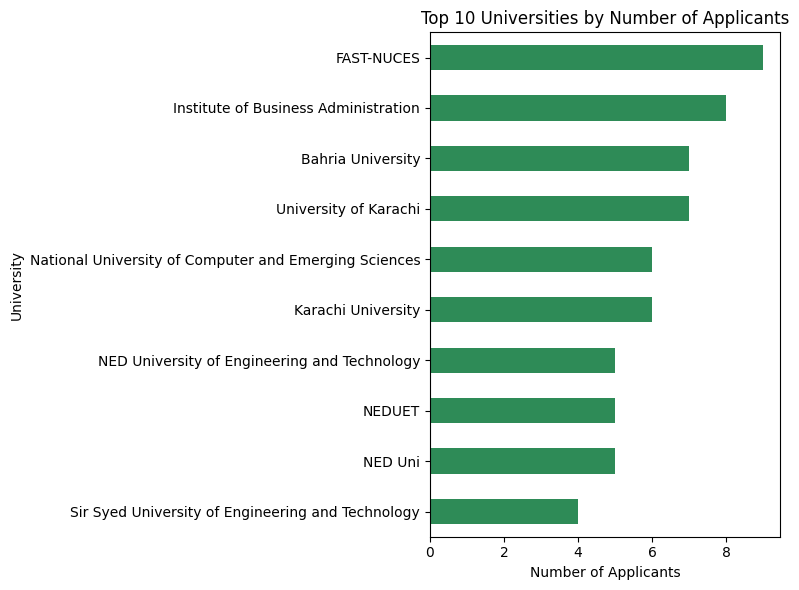

In [42]:
plt.figure(figsize=(8,6))
top_universities.sort_values().plot(kind='barh', color='seagreen')
plt.title('Top 10 Universities by Number of Applicants')
plt.xlabel('Number of Applicants')
plt.ylabel('University')
plt.tight_layout()
plt.show()

In [43]:
df['Day of Week'] = df['Application Date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['Day of Week'].value_counts().reindex(day_order)
print(day_counts)

Day of Week
Monday        6
Tuesday      13
Wednesday    12
Thursday      8
Friday       13
Saturday     17
Sunday       13
Name: count, dtype: int64


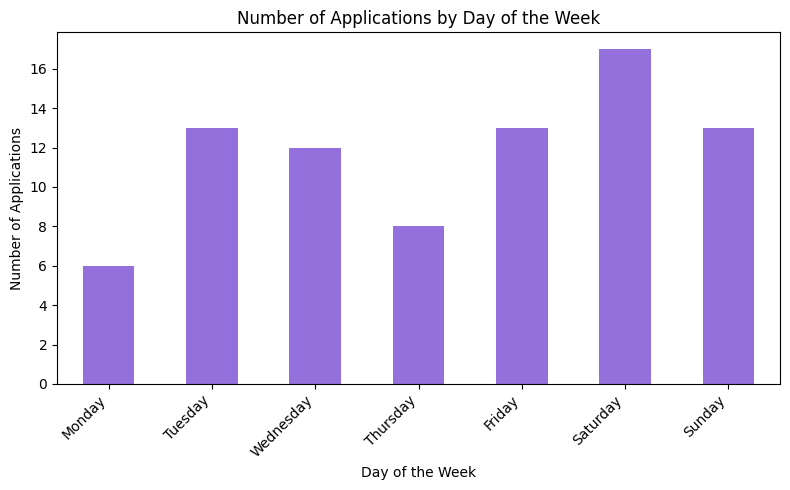

In [44]:
plt.figure(figsize=(8,5))
day_counts.plot(kind='bar', color='mediumpurple')
plt.title('Number of Applications by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()